In [ ]:
import gc
import torch

torch.cuda.empty_cache()
gc.collect()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from time import time

tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-2-7b-hf')
model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-2-7b-hf', device_map="auto")
model.hf_device_map

In [ ]:
q_proj_weight_7 = model.model.layers[7].self_attn.q_proj.weight
q_proj_weight_15 = model.model.layers[15].self_attn.q_proj.weight
q_proj_weight_23 = model.model.layers[23].self_attn.q_proj.weight

k_proj_weight_7 = model.model.layers[7].self_attn.k_proj.weight
k_proj_weight_15 = model.model.layers[15].self_attn.k_proj.weight
k_proj_weight_23 = model.model.layers[23].self_attn.k_proj.weight

v_proj_weight_7 = model.model.layers[7].self_attn.v_proj.weight
v_proj_weight_15 = model.model.layers[15].self_attn.v_proj.weight
v_proj_weight_23 = model.model.layers[23].self_attn.v_proj.weight

o_proj_weight_7 = model.model.layers[7].self_attn.o_proj.weight
o_proj_weight_15 = model.model.layers[15].self_attn.o_proj.weight
o_proj_weight_23 = model.model.layers[23].self_attn.o_proj.weight

mlp_gate_weight_7 = model.model.layers[7].mlp.gate_proj.weight
mlp_gate_weight_15 = model.model.layers[15].mlp.gate_proj.weight
mlp_gate_weight_23 = model.model.layers[23].mlp.gate_proj.weight

mlp_up_weight_7 = model.model.layers[7].mlp.up_proj.weight
mlp_up_weight_15 = model.model.layers[15].mlp.up_proj.weight
mlp_up_weight_23 = model.model.layers[23].mlp.up_proj.weight

mlp_down_weight_7 = model.model.layers[7].mlp.down_proj.weight
mlp_down_weight_15 = model.model.layers[15].mlp.down_proj.weight
mlp_down_weight_23 = model.model.layers[23].mlp.down_proj.weight

In [ ]:
from test_dbsf import *

In [ ]:
# diagram0a = test_double_sparse(matrix=k_proj_weight_7, mask_type='blocks', total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

In [ ]:
# diagram0b = test_double_sparse(matrix=q_proj_weight_7, mask_type='2to4', total_sp=0.5, b_bias=0.5, mid_dim_scale=1)

In [ ]:
# # q7 = test_double_block_sparse(q_proj_weight_7, 0.5, 0.5, 1)
# q15 = test_double_block_sparse(q_proj_weight_15, 0.5, 0.5, 1)
# # q23 = test_double_block_sparse(q_proj_weight_23, 0.5, 0.5, 1)

# # k7 = test_double_block_sparse(k_proj_weight_7, 0.5, 0.5, 1)
# k15 = test_double_block_sparse(k_proj_weight_15, 0.5, 0.5, 1)
# # k23 = test_double_block_sparse(k_proj_weight_23, 0.5, 0.5, 1)

# # mg7 = test_double_block_sparse(mlp_gate_weight_7, 0.5, 0.5, 1)
# mg15 = test_double_block_sparse(mlp_gate_weight_15, 0.5, 0.5, 1)
# # mg23 = test_double_block_sparse(mlp_gate_weight_23, 0.5, 0.5, 1)

# # md7 = test_double_block_sparse(mlp_down_weight_7, 0.5, 0.5, 1)
# md15 = test_double_block_sparse(mlp_down_weight_15, 0.5, 0.5, 1)
# # md23 = test_double_block_sparse(mlp_down_weight_23, 0.5, 0.5, 1)

# res = {
#     # "q7": q7,
#     "q15": q15,
#     # "q23": q23,
#     # "k7": k7,
#     "k15": k15,
#     # "k23": k23,
#     # "mg7": mg7,
#     "mg15": mg15,
#     # "mg23": mg23,
#     # "md7": md7,
#     "md15": md15,
#     # "md23": md23,
# }

# print(res)

In [ ]:
rho0 = {
    'q15': 105.1045913696289, 
    'k15': 108.2546615600586, 
    'mg15': 101.32691192626953, 
    'md15': 98.73725128173828
}
rho0_1 = {
    'q15': 41.81094741821289, 
    'k15': 43.086483001708984, 
    'mg15': 73.41590118408203, 
    'md15': 74.24418640136719
}
rho0_25 = {
    'q15': 24.419002532958984, 
    'k15': 25.219478607177734, 
    'mg15': 48.51237487792969, 
    'md15': 49.44807434082031
}
rho0_4 = {
    'q15': 23.110801696777344, 
    'k15': 23.8511905670166, 
    'mg15': 42.945472717285156, 
    'md15': 43.15519332885742
}
rho0_45 = {
    'q15': 23.10077476501465, 
    'k15': 23.839792251586914, 
    'mg15': 42.548973083496094, 
    'md15': 42.68795394897461
}
rho0_5 = {
    'q15': 23.122785568237305,
    'k15': 23.85993766784668,
    'mg15': 42.440006256103516, 
    'md15': 42.553592681884766, 
}
rho0_55 = {
    'q15': 23.170974731445312, 
    'k15': 23.907880783081055, 
    'mg15': 42.5140266418457, 
    'md15': 42.62941360473633
}
rho0_75 = {
    'q15': 23.569107055664062, 
    'k15': 24.309635162353516, 
    'mg15': 42.84531784057617, 
    'md15': 42.98478698730469
}
rho1 = {
    'q15': 24.298742294311523, 
    'k15': 25.035852432250977, 
    'mg15': 43.17190170288086, 
    'md15': 43.27824401855469, 
}

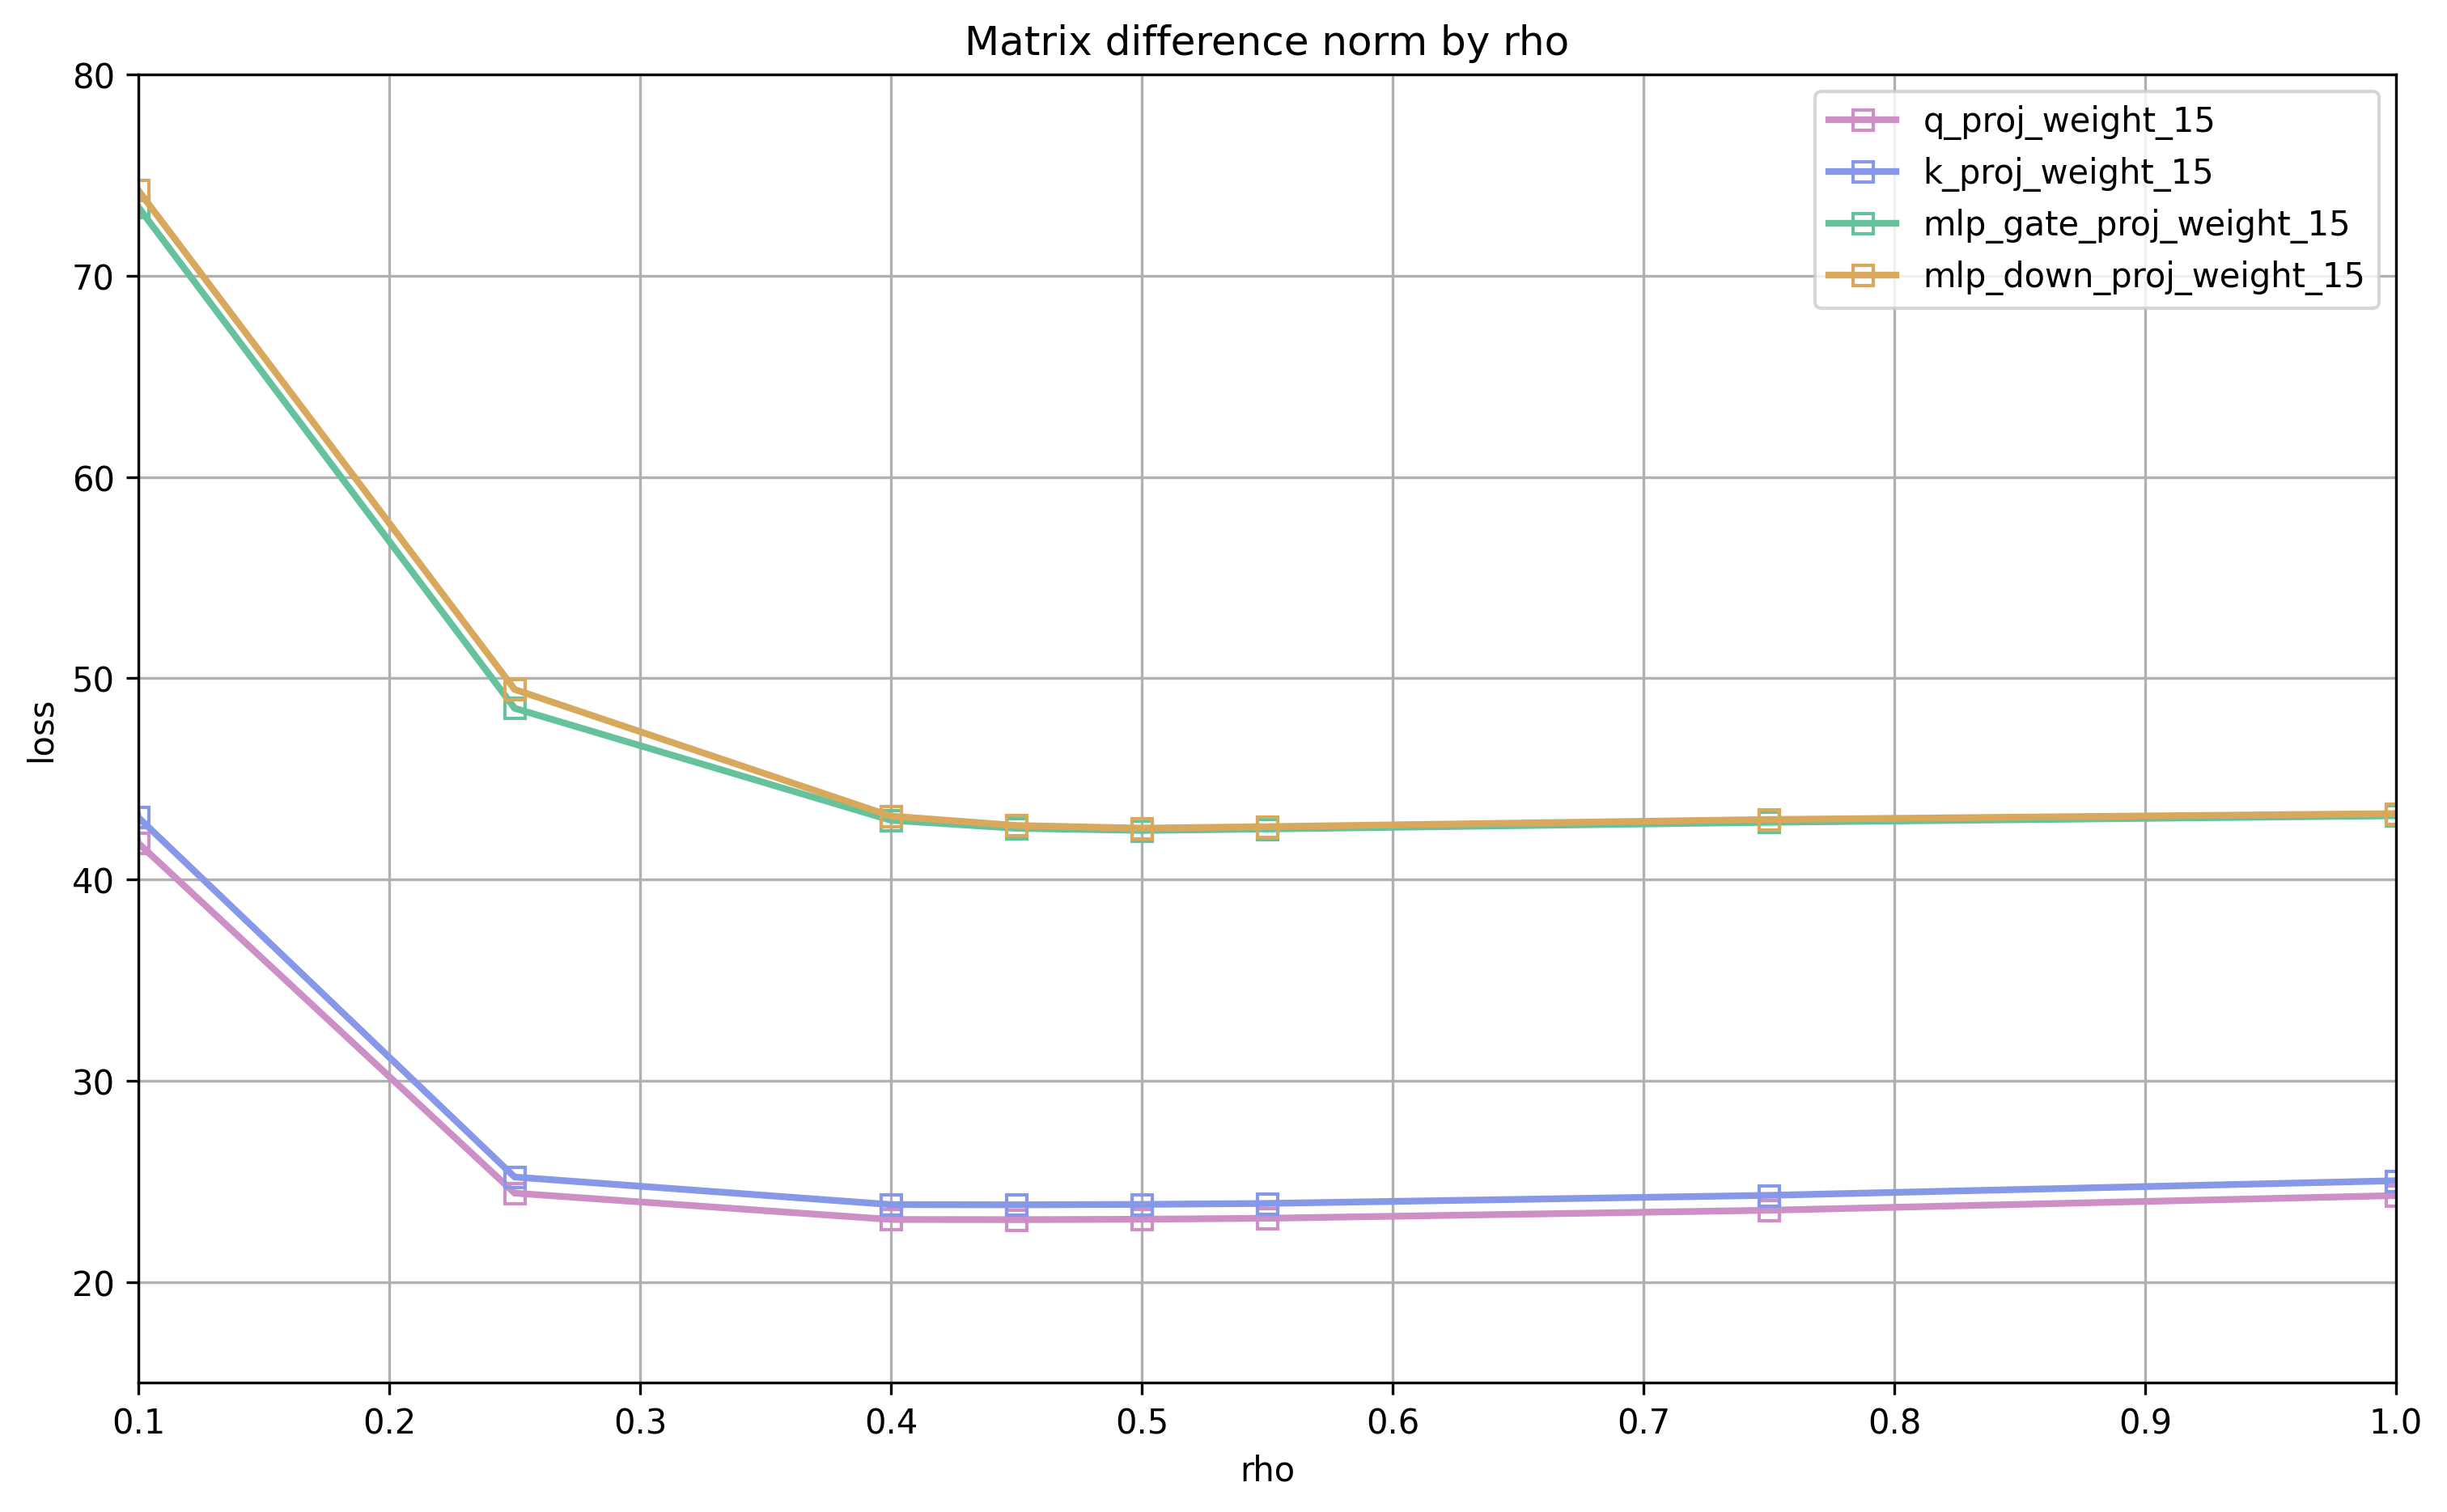

In [23]:
import matplotlib.pyplot as plt

# x-axis values
x = [0, 0.1, 0.25, 0.4, 0.45, 0.5, 0.55, 0.75, 1]

# y values
q15 = [105.1045913696289, 41.81094741821289, 24.419002532958984,
       23.110801696777344, 23.10077476501465, 23.122785568237305,
       23.170974731445312, 23.569107055664062, 24.298742294311523]

k15 = [108.2546615600586, 43.086483001708984, 25.219478607177734,
       23.8511905670166, 23.839792251586914, 23.85993766784668,
       23.907880783081055, 24.309635162353516, 25.035852432250977]

mg15 = [101.32691192626953, 73.41590118408203, 48.51237487792969,
        42.945472717285156, 42.548973083496094, 42.440006256103516,
        42.5140266418457, 42.84531784057617, 43.17190170288086]

md15 = [98.73725128173828, 74.24418640136719, 49.44807434082031,
        43.15519332885742, 42.68795394897461, 42.553592681884766,
        42.62941360473633, 42.98478698730469, 43.27824401855469]

# Larger figure
plt.figure(figsize=(12, 7), dpi=300)

# Plot with hollow square markers
plt.plot(x, q15, label='q_proj_weight_15', color="#CD90C6", marker='s',
         markerfacecolor='none', linewidth=2)
plt.plot(x, k15, label='k_proj_weight_15', color="#8898E8", marker='s',
         markerfacecolor='none', linewidth=2)
plt.plot(x, mg15, label='mlp_gate_proj_weight_15', color="#66C29D", marker='s',
         markerfacecolor='none', linewidth=2)
plt.plot(x, md15, label='mlp_down_proj_weight_15', color="#D8A95C", marker='s',
         markerfacecolor='none', linewidth=2)

# Axis limits
plt.xlim(0.2, 1)
plt.ylim(15, 80)
plt.xticks([i/10 for i in range(1, 11)])

# Labels and legend
plt.xlabel('rho')
plt.ylabel('loss')
plt.legend()
plt.title('Matrix difference norm by rho')

# Grid
plt.grid(True)
plt.show()

In [ ]:
# q7_2x2 = test_double_sparse(q_proj_weight_7, 0.5, 0.5, 1, mask_type='blocks_alt')
# q15_2x2 = test_double_sparse(q_proj_weight_15, 0.5, 0.5, 1, mask_type='blocks_alt')
# q23_2x2 = test_double_sparse(q_proj_weight_23, 0.5, 0.5, 1, mask_type='blocks_alt')

In [ ]:
q7_1x1 = 10.132308006286621
q15_1x1 = 10.241986274719238
q23_1x1 = 10.641284942626953

q7_2x1_colrow = 17.123369216918945
q15_2x1_colrow = 17.54688835144043
q23_2x1_colrow = 18.129613876342773

# q7_2x1_rowrow = 17.125669479370117
# q15_2x1_rowrow = 17.55666732788086
# q23_2x1_rowrow = 18.12950897216797

# q7_2x1_colcol = 17.140546798706055
# q15_2x1_colcol = 17.563806533813477
# q23_2x1_colcol = 18.14604377746582

# q7_2x1_rowcol = 17.15144157409668
# q15_2x1_rowcol = 17.572513580322266
# q23_2x1_rowcol = 18.153913497924805

q7_2x2 = 23.453115463256836
q15_2x2 = 24.298742294311523
q23_2x2 = 25.018169403076172

q7_4x4 = 30.620349884033203
q15_4x4 = 32.03445816040039
q23_4x4 = 33.268218994140625

q7_8x8 = 37.110137939453125
q15_8x8 = 39.21969223022461
q23_8x8 = 40.96297073364258

q7_16x16 = 39.02204132080078
q15_16x16 = 40.88953399658203
q23_16x16 = 47.2333869934082

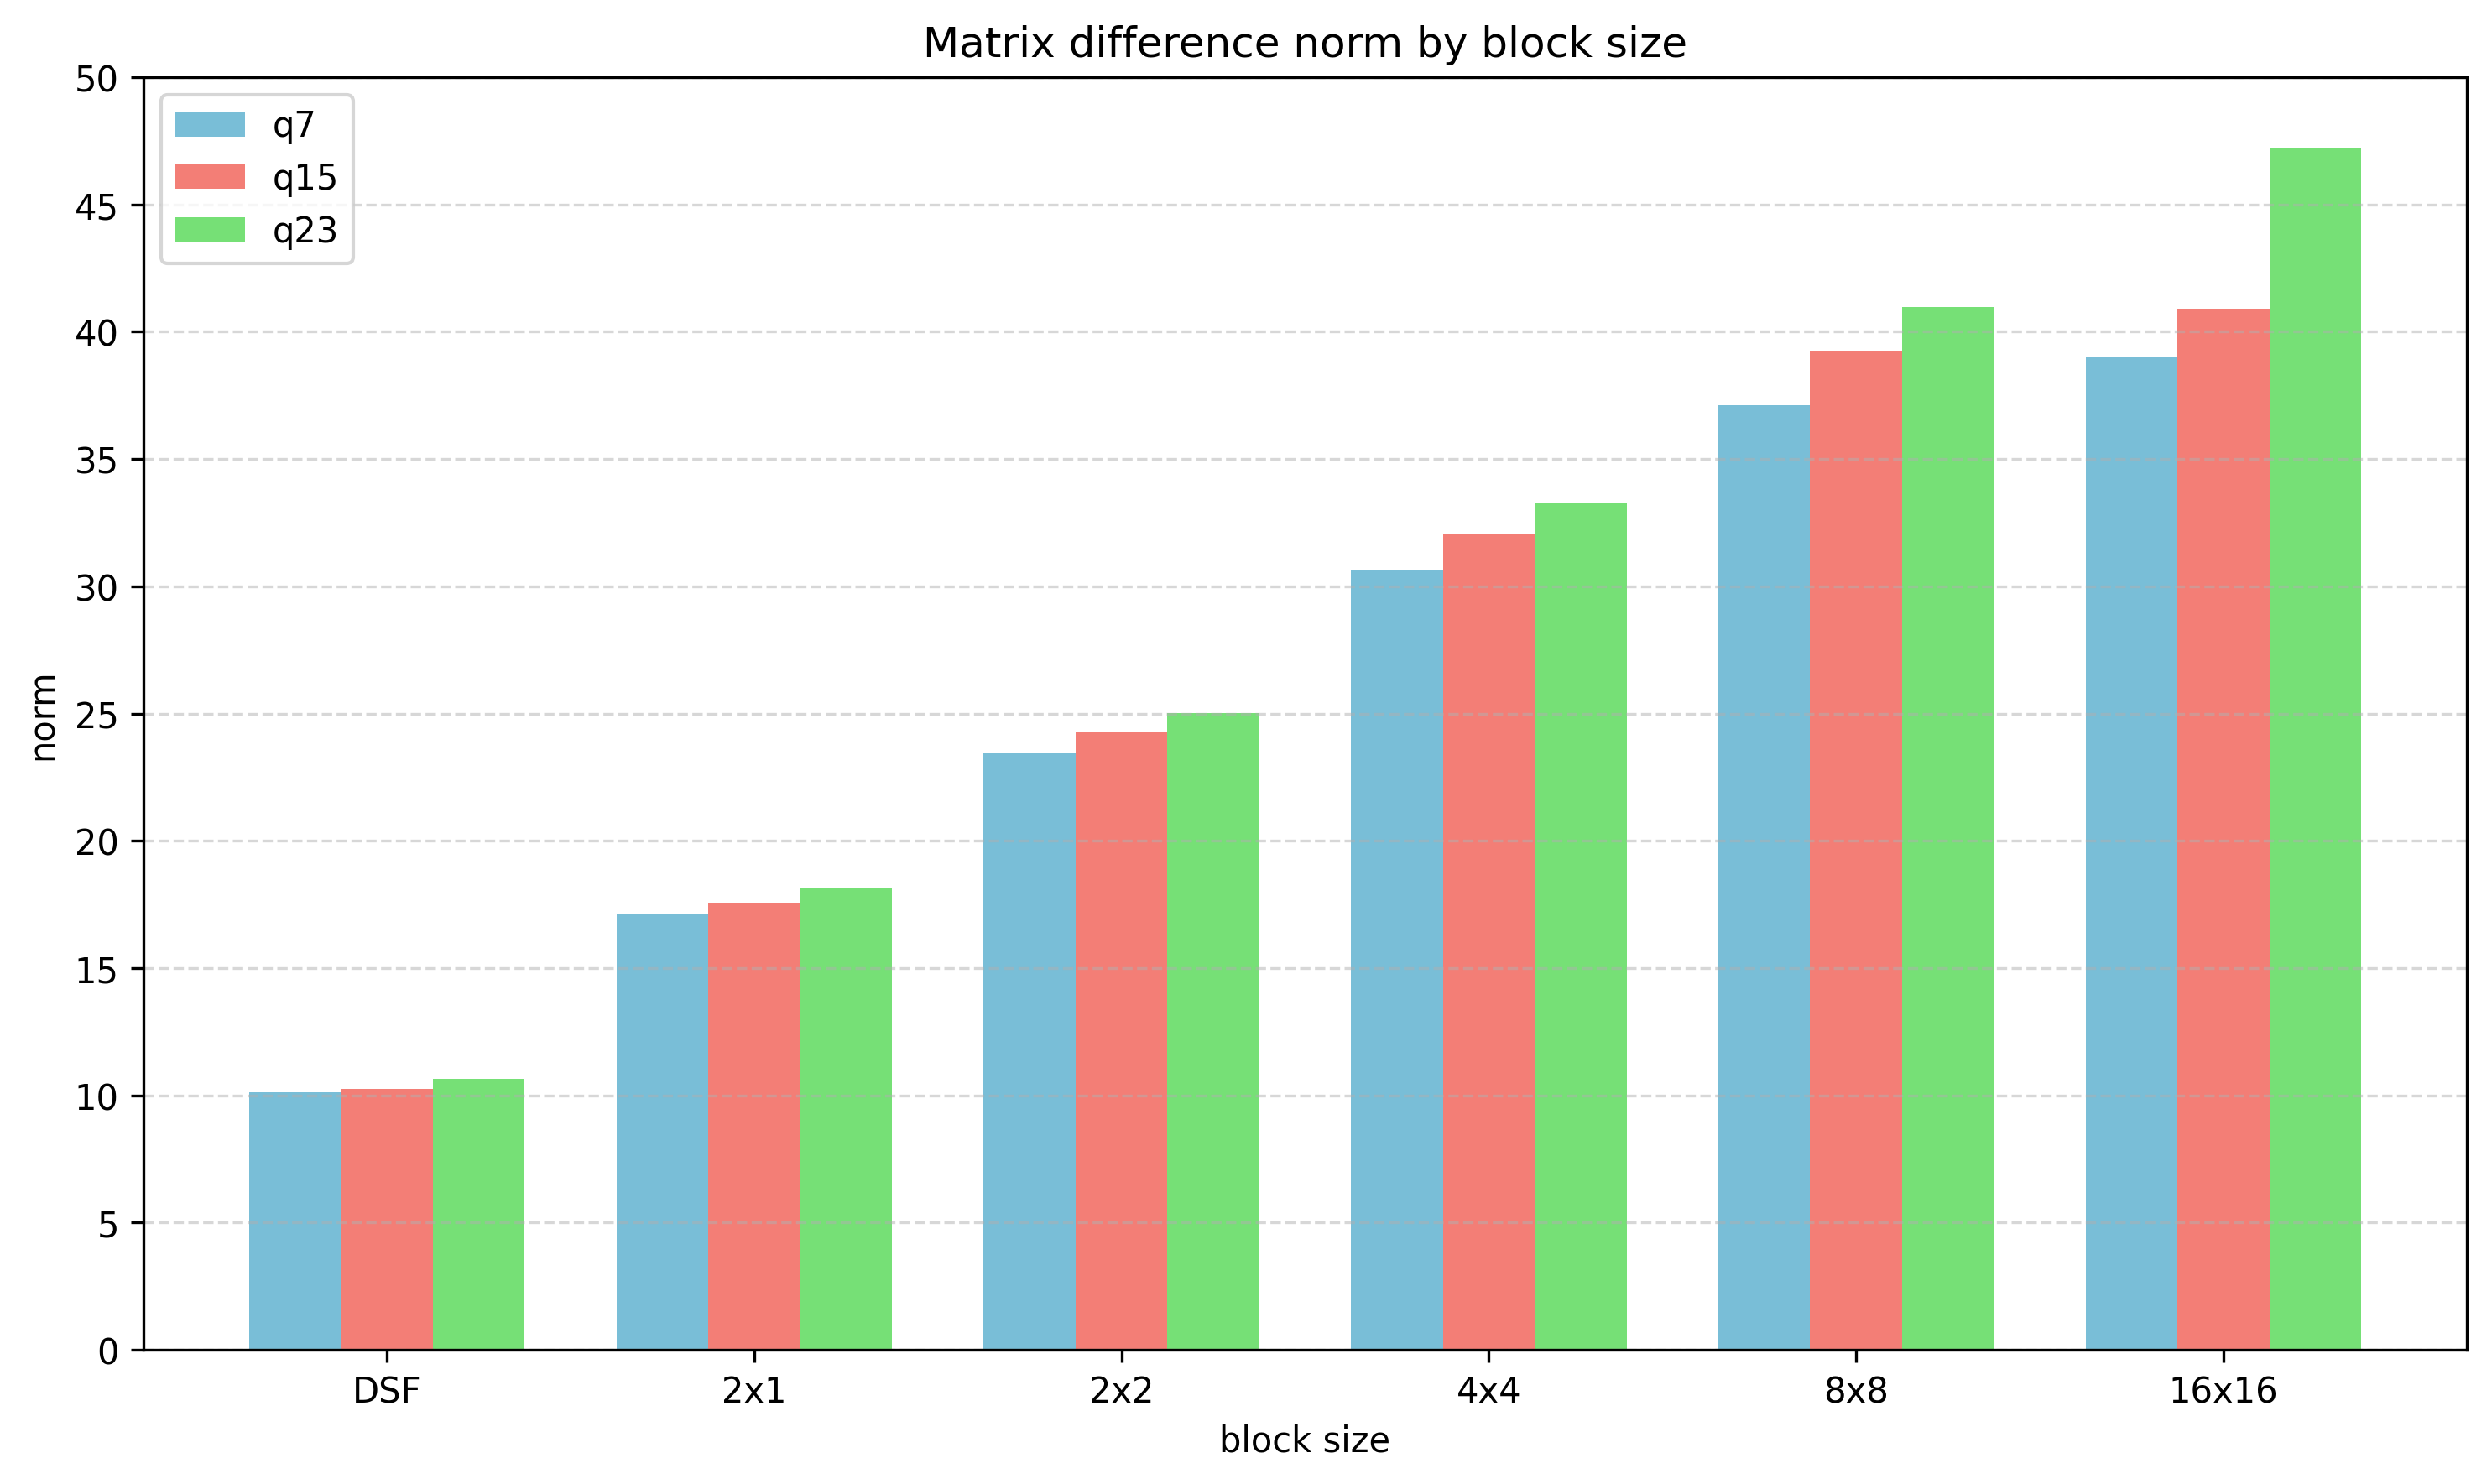

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Groups
groups = ['DSF', '2x1', '2x2', '4x4', '8x8', '16x16']
x = np.arange(len(groups))

# Values
q7  = [10.1323, 17.1234, 23.4531, 30.6203, 37.1101, 39.0220]
q15 = [10.2420, 17.5469, 24.2987, 32.0345, 39.2197, 40.8895]
q23 = [10.6413, 18.1296, 25.0182, 33.2682, 40.9630, 47.2334]

# Bar width
width = 0.25

# Figure (high DPI)
plt.figure(figsize=(10, 6), dpi=300)

# Pastel colors (same across groups)
color_q7  = "#79BED7"  # pastel blue
color_q15 = "#F37E76"  # pastel red
color_q23 = "#76E076"  # pastel green

# Plot grouped bars
plt.bar(x - width, q7,  width, label='q7',  color=color_q7)
plt.bar(x,         q15, width, label='q15', color=color_q15)
plt.bar(x + width, q23, width, label='q23', color=color_q23)

# Axes formatting
plt.xticks(x, groups)
plt.ylim(0, 50)
plt.yticks(np.arange(0, 51, 5))

# Labels & legend
plt.xlabel('block size')
plt.ylabel('norm')
plt.title('Matrix difference norm by block size')
plt.legend()

# Grid (optional but helps readability)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# q7_2x2 = test_double_sparse(q_proj_weight_7, 0.5, 0.5, 1, mask_type='blocks')
# q15_2x2 = test_double_sparse(mlp_down_weight_15, 0.5, 0.5, 1, mask_type='blocks')

In [ ]:
q7_2x2_125p_375p = 23.643545150756836
q15_2x2_125p_375p = 24.829833984375
q23_2x2_125p_375p = 25.581159591674805

q7_2x2_20p_30p = 23.164443969726562
q15_2x2_20p_30p = 24.083036422729492
q23_2x2_20p_30p = 24.837310791015625

q7_2x2_25p_25p = 23.453115463256836
q15_2x2_25p_25p = 24.298742294311523
q23_2x2_25p_25p = 25.018169403076172

q7_2x2_375p_125p = 26.42716407775879
q15_2x2_375p_125p = 27.068979263305664
q23_2x2_375p_125p = 27.9689884185791


o7_2x2_125p_375p = 17.115551
o15_2x2_125p_375p = 19.705472946166992
o23_2x2_125p_375p = 25.003847122192383

o7_2x2_20p_30p = 16.28129005432129
o15_2x2_20p_30p = 18.71734046936035
o23_2x2_20p_30p = 23.90760612487793

o7_2x2_25p_25p = 16.217567443847656
o15_2x2_25p_25p = 18.643760681152344
o23_2x2_25p_25p = 23.848196029663086

o7_2x2_375p_125p = 17.73960304260254
o15_2x2_375p_125p = 20.45415496826172
o23_2x2_375p_125p = 26.226451873779297


mlpup7_2x2_407p_25p = 41.632450103759766
mlpup15_2x2_407p_25p = 44.01103210449219
mlpup23_2x2_407p_25p = 44.097938537597656

mlpup7_2x2_360p_375p = 40.40531539916992
mlpup15_2x2_360p_375p = 42.69010543823242
mlpup23_2x2_360p_375p = 42.748512268066406

mlpup7_2x2_314p_50p = 40.26658248901367
mlpup15_2x2_314p_50p = 42.532840728759766
mlpup23_2x2_314p_50p = 42.59101486206055


mlpdown7_2x2_407p_25p = 40.1270751953125
mlpdown15_2x2_407p_25p = 43.27824401855469
mlpdown23_2x2_407p_25p = 44.18965148925781

mlpdown7_2x2_360p_375p = 38.80428695678711
mlpdown15_2x2_360p_375p = 41.95237731933594
mlpdown23_2x2_360p_375p = 42.881065368652344

mlpdown7_2x2_314p_50p = 38.57448196411133
mlpdown15_2x2_314p_50p = 41.790103912353516
mlpdown23_2x2_314p_50p = 42.743751525878906

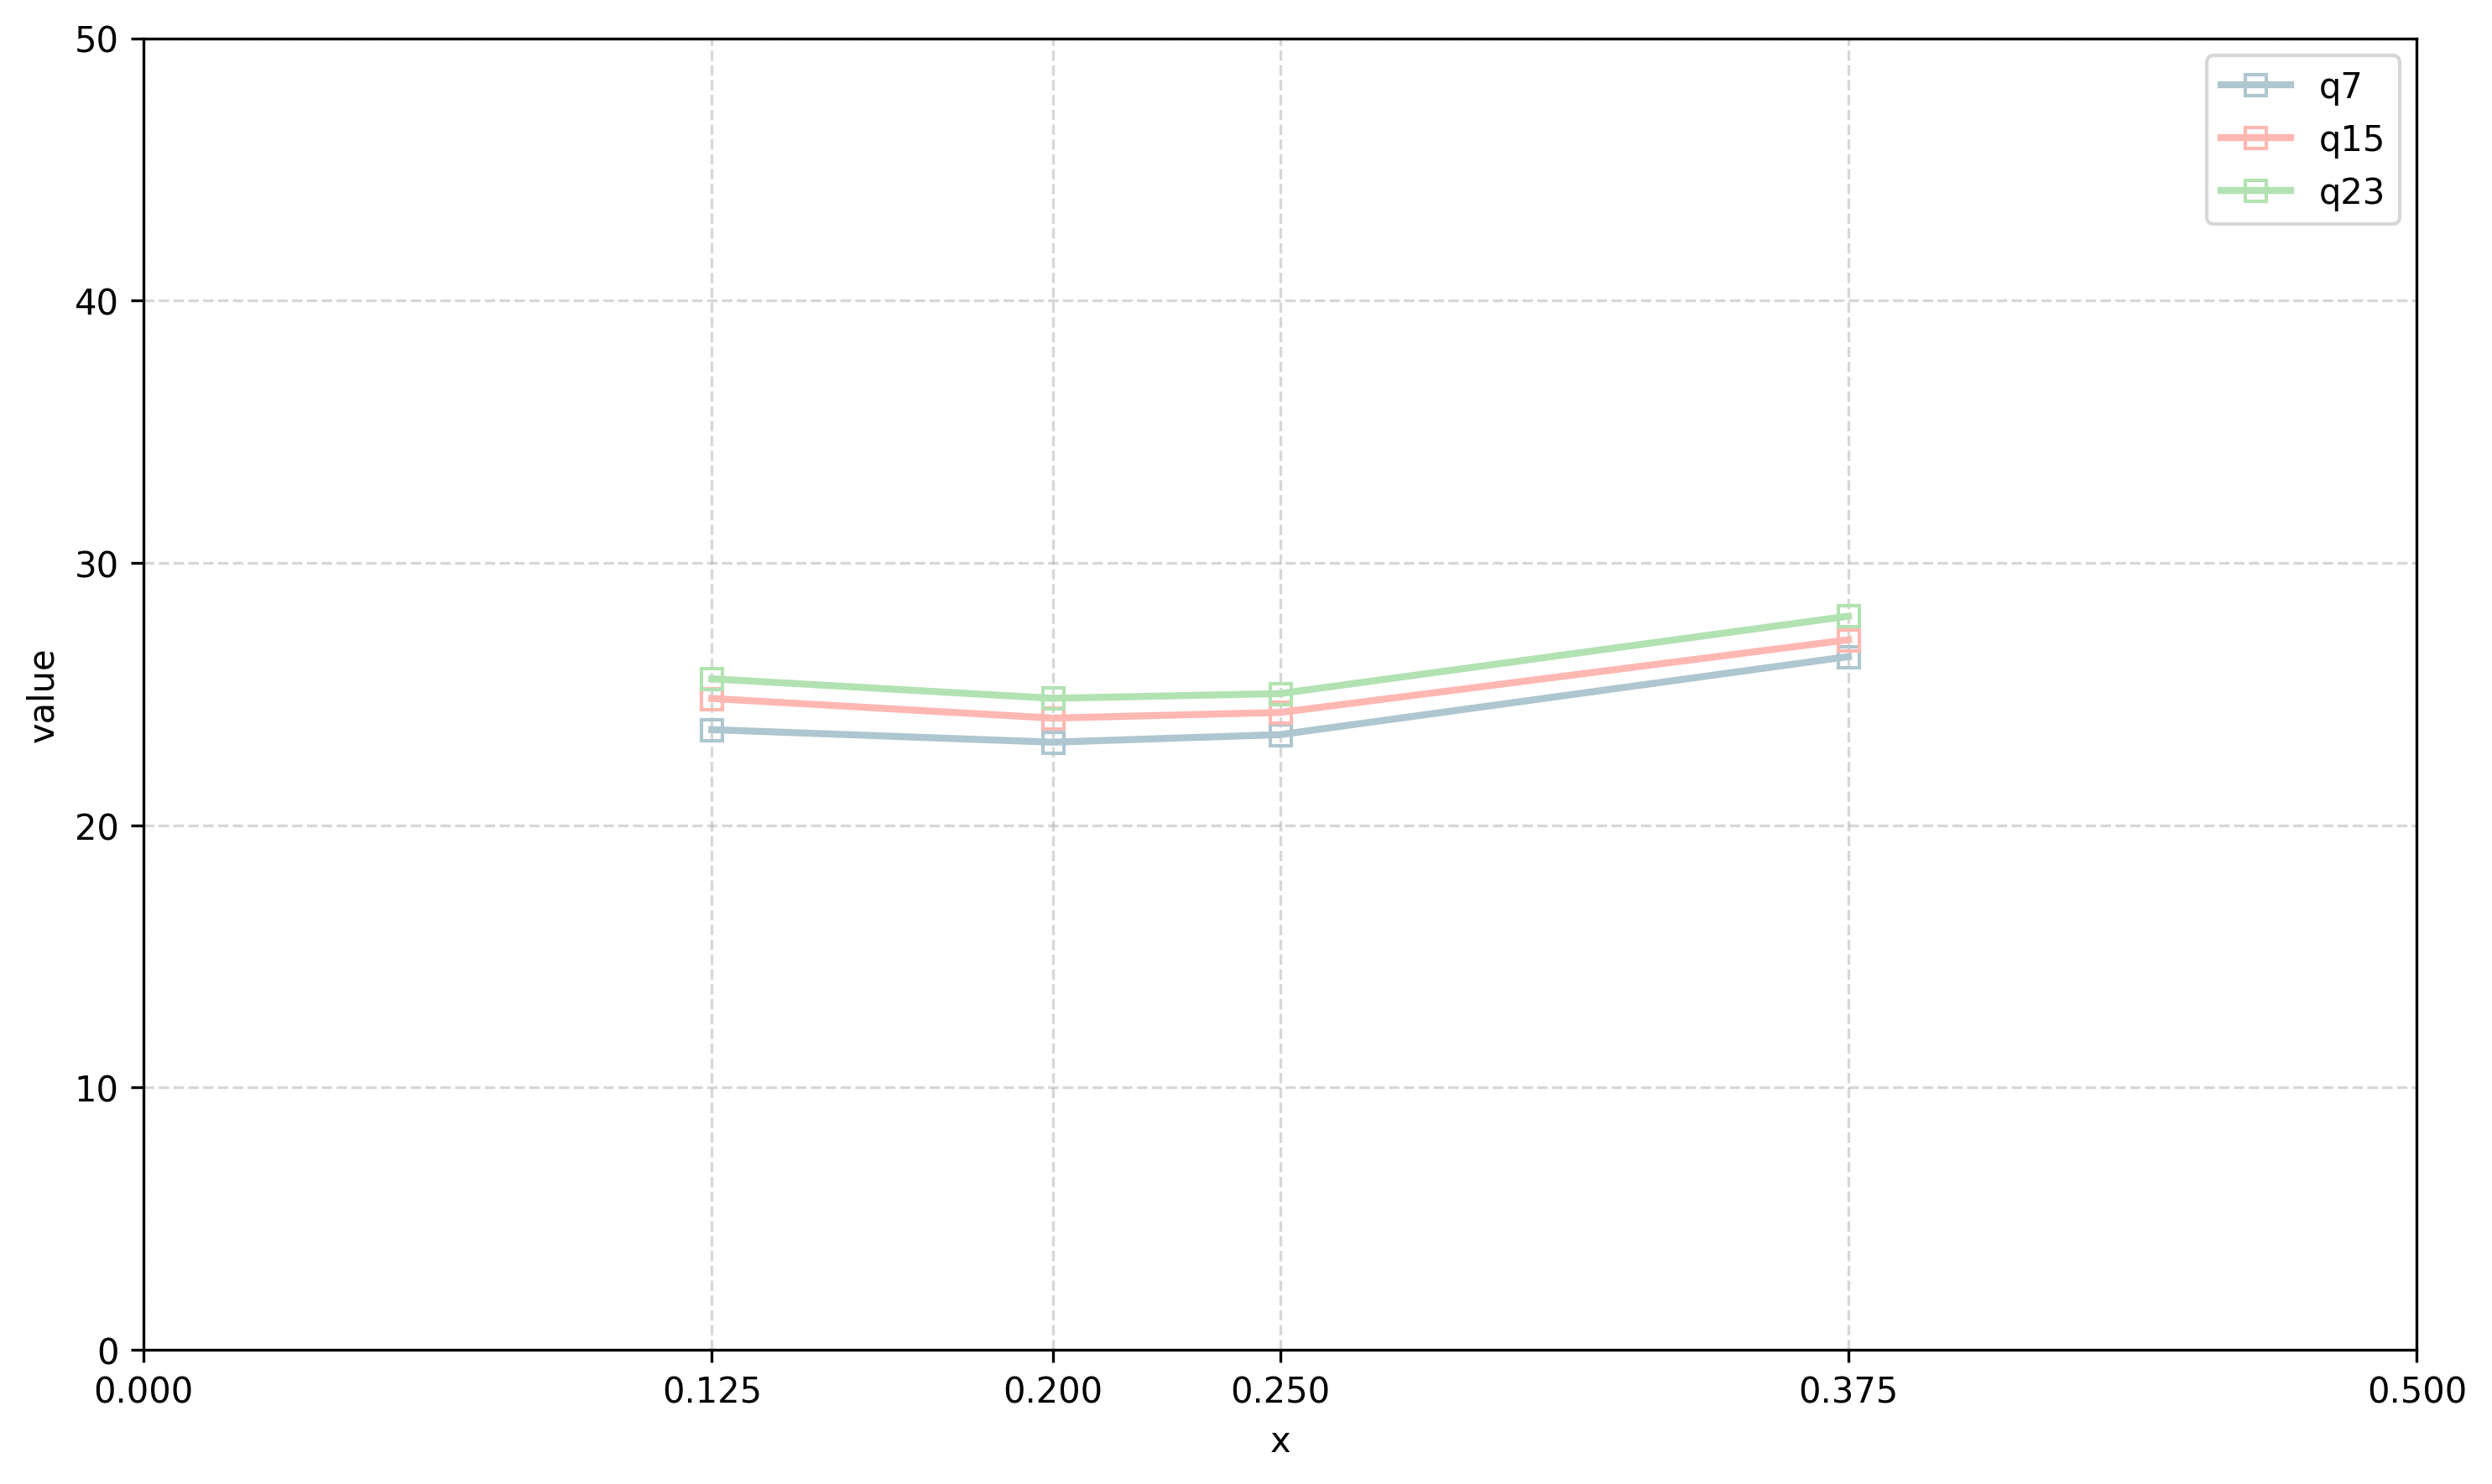

In [ ]:
import matplotlib.pyplot as plt

# x values
x = [0.125, 0.2, 0.25, 0.375]

# y values
q7  = [23.643545150756836, 23.164443969726562, 23.453115463256836, 26.42716407775879]
q15 = [24.829833984375,    24.083036422729492, 24.298742294311523, 27.068979263305664]
q23 = [25.581159591674805, 24.837310791015625, 25.018169403076172, 27.9689884185791]

# Figure
plt.figure(figsize=(10, 6), dpi=300)

# Plot lines (pastel colors + hollow square markers)
plt.plot(x, q7,  label='q7',  color='#AEC6CF', marker='s', markerfacecolor='none', linewidth=2)
plt.plot(x, q15, label='q15', color='#AEC6CF', marker='s', markerfacecolor='none', linewidth=2)
plt.plot(x, q23, label='q23', color='#AEC6CF', marker='s', markerfacecolor='none', linewidth=2)

# Axes
plt.xlim(0, 0.5)
plt.ylim(0, 50)

# Optional: nice ticks
plt.xticks([0.0, 0.125, 0.2, 0.25, 0.375, 0.5])

# Labels & legend
plt.xlabel('x')
plt.ylabel('value')
plt.legend()

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# start = time()
# q15_2x2 = test_double_sparse(q_proj_weight_15, 0.5, 0.5, 1, mask_type='blocks_alt')
# end = time() - start
# print(end)

In [ ]:
# start = time()
# mlpup_2x2 = test_double_sparse(mlp_up_weight_15, 0.5, 0.5, 1, mask_type='blocks_alt')
# end = time() - start
# print(end)

In [ ]:
q15_dsf_secs = 17.998
mlpup_dsf_secs = 32.483

q15_2x2_secs = 20.397
q15_2x2_secs_middim2 = 61.065
mlpup_2x2_secs = 38.630

q15_2x1_secs = 25.257
q15_2x1_secs_middim2 = 68.914
mlpup_2x1_secs = 46.979

q15_2to4_secs = 25.037
q15_2to4_secs_middim2 = 74.769
mlpup_2to4_secs = 47.045

qwen3_k15_secs = 3.4195



q15_2to4_norm = 14.211647987365723
q15_2to4_secs = 24.622774600982666

q15_2to4_cp_norm = 14.22008991241455
q15_2to4_cp_secs = 25.32834

q15_2to4_cp12_norm = 14.218571662902832
q15_2to4_cp12_secs = 25.25075674057007


mlpup15_2to4_norm = 27.17522430419922
mlpup15_2to4_secs = 46.42337131500244

mlpup15_2to4_cp_norm = 27.17560
mlpup15_2to4_cp_secs = 47.34501099586487

mlpup15_2to4_cp12_norm = 27.17211151123047
mlpup15_2to4_cp12_secs = 47.462169885635376


q15_2x1_norm = 17.54688835144043
q15_2x1_secs = 25.020596265792847

q15_2x1_cp_norm = 17.53778648376465
q15_2x1_cp_secs = 25.488643646240234

q15_2x1_cp12_norm = 17.54064178466797
q15_2x1_cp12_secs = 25.448254585266113

mlpup15_2x1_norm = 32.630680084228516
mlpup15_2x1_secs = 46.44873905181885

mlpup15_2x1_cp_norm = 32.62998962402344
mlpup15_2x1_cp_secs = 47.38391351699829

mlpup15_2x1_cp12_norm = 32.63258743286133
mlpup15_2x1_cp12_secs = 47.5490882396698

In [ ]:
from time import time
from test_dbsf import *

start = time()
q15_2x2 = test_double_sparse(v_proj_weight_23, 0.5, 0.5, 1, mask_type='blocks_alt')
end = time() - start
print(end)

In [ ]:
mlpdown7_2x2_no_tetris = 38.5744819641113
mlpdown7_2x2_no_tetris_seconds = 38.51993656158447

mlpdown7_2x2_tetris = 38.60469055175781
mlpdown7_2x2_tetris_seconds = 91.65945792198181

mlpdown7_2x2_tetris_it3 = 38.58454132080078
mlpdown7_2x2_tetris_it3_seconds = 91.54047346115112

mlpdown7_2x2_tetris_it1 = 38.61601257324219
mlpdown7_2x2_tetris_it1_seconds = 91.21226334571838

mlpdown7_2x1_no_tetris = 29.536575317382812
mlpdown7_2x1_no_tetris_seconds = 47.718810081481934

mlpdown7_2x1_tetris = 29.06410789489746
mlpdown7_2x1_tetris_seconds = 101.11837577819824

mlpdown7_2to4_no_tetris = 24.607154846191406
mlpdown7_2to4_no_tetris_seconds = 46.1153826713562

mlpdown7_2to4_tetris = 24.1757755279541
mlpdown7_2to4_tetris_seconds = 100.62246894836426


q15_2x2_no_tetris = 24.29874
q15_2x2_no_tetris_seconds = 20.80595636367798

q15_2x2_tetris = 24.0827579498291
q15_2x2_tetris_seconds = 49.422743797302246

q15_2x1_no_tetris = 17.54064178466797
q15_2x1_no_tetris_seconds = 25.550762176513672

q15_2x1_tetris = 17.169456481933594
q15_2x1_tetris_seconds = 55.11411213874817

q15_2to4_no_tetris = 14.211647987365723
q15_2to4_no_tetris_seconds = 24.84253716468811

q15_2to4_tetris = 14.029687881469727
q15_2to4_tetris_seconds = 54.16424369812012



mlpdown15_2x2_no_tetris = 41.790103912353516
mlpdown15_2x2_no_tetris_seconds = 39.063907623291016

mlpdown15_2x2_tetris = 41.841922760009766
mlpdown15_2x2_tetris_seconds = 91.90242910385132

mlpdown15_2x1_no_tetris = 32.0628547668457
mlpdown15_2x1_no_tetris_seconds = 47.86954092979431

mlpdown15_2x1_tetris = 31.56764030456543
mlpdown15_2x1_tetris_seconds = 101.29106450080872

mlpdown15_2to4_no_tetris = 26.711050033569336
mlpdown15_2to4_no_tetris_seconds = 46.58864617347717

mlpdown15_2to4_tetris = 26.25615692138672
mlpdown15_2to4_tetris_seconds = 101.03820538520813


v23_2x1_no_tetris = 16.899744033813477
v23_2x1_no_tetris_seconds = 25.610812425613403

v23_2x1_tetris = 16.485729217529297
v23_2x1_tetris_seconds = 54.967862606048584

v23_2to4_no_tetris = 13.367036819458008
v23_2to4_no_tetris_seconds = 24.876603603363037

v23_2to4_tetris = 13.006450653076172
v23_2to4_tetris_seconds = 53.673781394958496